In [94]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d


We want to find the $k$-dependent eigenvalues of matrix $\boldsymbol{A}(k)$. If, for a given temperature $\beta$, all eigenvalues for all $k$ are negative, the uniform distribution is stable and no clustering will occur.
The matrix depends on the pairwise interaction potential $W$ (rather, its Fourier transform).  
First, we define two functions. One computes matrix $\boldsymbol{A}$, the other one computes the spectral radii of $\boldsymbol{A}$ for a range of $\gamma$, $\beta$ and $k$ values.

In [129]:
# Matrix A(k) for given Fourier coefficient \hat{W}(k) at fixed k, beta, gamma, L. 
# We truncate it after the first "dim" rows/columns.

def A_matrix(W_hat, k, beta, gamma, L, dim):
    
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    
    for i in range(dim-1):
        A_k[i][i] = i*(-gamma) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/beta)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/beta)*1j 
    
    A_k[dim-1][dim-1] = (dim-1)*(-gamma)
    
    A_k[1][0] += -k*np.sqrt(beta)*1j*W_hat(k)/L  
    
    return A_k




# For a given number of beta and gamma values, and wavenumbers up to k_max, this function yields 
# the spectral radius of A(k) for each of them. It uses A_matrix from above.

def compute_spectral(W_hat, k_max, beta_list, gamma_list, L, dim ):

    N_beta = len(beta_list)
    N_gamma = len(gamma_list)
    
    spectral_radius = np.zeros((N_beta, N_gamma))  # Store spectral radius.
    
    
    for i in range(len(beta_list)):
        
        beta = beta_list[i]
        print("Testing beta ", beta)
        
        for j in range(len(gamma_list)):
            
            gamma = gamma_list[j]
            
            # Get spectral radius for k=0.
            matrix = A_matrix(W_hat, 0, beta, gamma, L, dim)
            maximum = np.max( np.real( np.linalg.eigvals(matrix) ) ) 
            
            # Test all other wavenumbers.
            for z in range(1, k_max):
                
                k = 2*np.pi*z/L
                
                matrix = A_matrix(W_hat, k, beta, gamma, L, dim)
                
                partial_max = np.max( np.real( np.linalg.eigvals(matrix) ) )
                
                if partial_max > maximum:
                    maximum = partial_max
                
                
                # Test negative k.
                k = -k 
                matrix = A_matrix(W_hat, k, beta, gamma, L, dim)
                partial_max = np.max( np.real( np.linalg.eigvals(matrix) ) )
                
                if partial_max > maximum:
                    maximum = partial_max
            
            spectral_radius[i,j] = maximum
    
    return spectral_radius

In [174]:
def plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, pot_name):
    
    
    ### Plot spectral radius against beta at fixed gamma. ###

    
    plt.plot(beta_list, spectral_radius[:, gamma_idx])

    plt.title('γ='+str(gamma_list[gamma_idx]))
    plt.xlabel('β')
    plt.ylabel('Spectral radius')

    plt.show()

    print("\n")



    ### Plot spectral radius vs. (gamma, beta). ###

    fig = plt.figure(figsize =(10,15))
    ax = plt.axes(projection ='3d')

    X, Y = np.meshgrid(gamma_list, beta_list)

    surf = ax.plot_surface(X, Y, spectral_radius, cmap = plt.cm.cividis)

    ax.set_xlabel('γ', labelpad=20)
    ax.set_ylabel('β', labelpad=20)
    ax.set_zlabel('spectral radius', labelpad=20)
    ax.set_title('Spectral Radius, ' + pot_name)

    fig.colorbar(surf, shrink=0.5, aspect=20, pad=0.15)

    plt.show()


    print("\n")


    ### Plot time to onset of clustering for fixed gamma at beta > beta_c. ###

    N_particle = 1000

    t_cl = np.log(N_particle)/(2*spectral_radius[-1,:])      # See main text.

    plt.plot(gamma_list, t_cl)
    plt.title(f'Time to clustering onset ({N_particle} particles),  ' + pot_name + ',  β='+str(beta_list[-1]))
    plt.xlabel('γ')
    plt.ylabel(r"$t_{\text{cl}}$")

<br>

# Gaussian Potential 

Since we are on the torus, we may use the periodic extension of the Gaussian interaction potential, which will ease the calculation.  
The potential is given by 
$$W(r) = -\sum^{\infty}_{n=-\infty}\exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}.$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by

$$
\begin{align}
\hat{W}(k) &= \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}-ikr\right)}dr, \\
           &=- \sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr, \\
           &= -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\cos{(kr)}dr,\\
           &= -\int^{\infty}_{-\infty} \exp{\left(-\frac{r^{2}}{2\sigma^{2}}\right)}\cos{\left(\frac{2\pi z r}{L}\right)}dr, \\
           &= -\sqrt{2\pi \sigma^2}e^{-2\sigma^{2}\pi^{2}z^{2}/L^{2}} = -\sqrt{2\pi \sigma^2} e^{-\sigma^{2}k^{2}/2}.
\end{align}
$$


An alternative is to use the non-periodic Gaussian (the one actually considered in the simulation):

$$ 
\hat{W}(k)=-\int_{-\frac{L}{2}}^{\frac{L}{2}} e^{\frac{r^2}{2\sigma^2}}e^{-ikr}dr=...=-\sqrt{\frac{\pi \sigma^2}{2}}e^{-\frac{k^2\sigma^2}{2}}\left[ erf\left( \frac{\frac{L}{2}-ik\sigma^2}{\sqrt{2\sigma^2}} \right) +erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right] = -\sqrt{2\pi\sigma^2} e^{-\frac{-k^2\sigma^2}{2}}Re\left( erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right).
$$

Here, $erf$ denotes the error function. Since $\frac{\sigma}{L}$ is small, the differences between the two expressions are exponentially small.

In [113]:
# Fourier transform of the Gaussian interaction.

sigma = np.sqrt(0.5)    # Width.
L = 10                  # Boxlength.

# Wrapped / periodic Gaussian.
def W_hat_gauss(k):
    W_hat_k = -np.sqrt(2*np.pi)*sigma*np.exp(-sigma**2 * k**2 /2) 
    return W_hat_k

# Non-wrapped case:
#from scipy.special import erf
#def W_hat_gauss(k):
#    W_hat_k = -np.sqrt(2*np.pi)*sigma * np.exp(-sigma**2*k**2/2)*np.real( erf( (0.5*L + 1j*k*sigma**2)/(np.sqrt(2*sigma**2)) ) )
#    return W_hat_k


In [114]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 100
beta_list = np.linspace(1, 10, N_beta)

N_gamma = 10
gamma_list = np.linspace(0.01, 1, N_gamma)

dim = 50    # Pick large enough such that results converge.

k_max = 50  # Pick large enough such that results converge.

spectral_radius = compute_spectral(W_hat_gauss, k_max, beta_list, gamma_list, L, dim)

Testing beta  1.0
Testing beta  2.0
Testing beta  3.0
Testing beta  4.0
Testing beta  5.0
Testing beta  6.0
Testing beta  7.0
Testing beta  8.0
Testing beta  9.0
Testing beta  10.0


In [120]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )


Linear stability analysis result for critical Beta:  7.0




Formula for critical beta $\beta_c$ for the Gaussian interaction by Martzel & Aslangul (2001):

$ \Huge \beta_c = \frac{L^d}{(2\pi)^{\frac{d}{2}}\sigma^d}$  

for dimensionality $d$ ($d=1$ in our case). 

In [121]:
# Print critical beta given by literature (Martzel & Aslangul, 2001).

print('Theoretical critcal beta in 1D ', L/(sigma*np.sqrt(2*np.pi)))
print('Theoretical critcal beta in 2D ', L**2/(sigma**2*2*np.pi)) 
print('Theoretical critcal beta in 3D ', L**3/(sigma**3*(2*np.pi)**(3/2)))


Theoretical critcal beta in 1D  5.6418958354775635
Theoretical critcal beta in 2D  31.83098861837906
Theoretical critcal beta in 3D  179.58712212516653


The deviations between the literature result (in 1D) and our result decrease for smaller $\frac{\sigma}{L}$ as can be easily verified be re-running the script for different values of $L$ and $\sigma$. See also Sec. REF in the supplementary material.

In [ ]:
plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, "Gauss Potential")

As can be seen from the second plot, $\beta_c$ is independent of friction $\gamma$ as expected.

From the final plot, we observe an overall linear regime of $t_{\text{cl}}$ with an upward bending for $\gamma \to 0$ (consistent with the simulation results in the main text).

<br>

# Morse potential

The Morse potential is given by $$W(r) = D_{e}(e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)}).$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by
$$\hat{W}(k) =  \int^{L/2}_{-L/2} W(r)\cos{(kr)}dr. $$
In contrast to the Gaussian case, we have to resort to numerical quadrature to evaluate $\hat{W}(k)$.

In [176]:
from scipy.integrate import quad

L  = 10
De = 1
re = 0
a  = 2

def integrand_morse(r, k):
    res = De * ( np.exp(-2*a*(np.abs(r)-re)) - 2*np.exp(-a*(np.abs(r)-re)) ) * np.cos(k*r)
    return res 

def W_hat_morse(k):
    W_hat_k = quad(integrand_morse, -L/2, L/2, args=(k))
    return W_hat_k[0]

In [177]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 100
beta_list = np.linspace(1, 20, N_beta)

N_gamma = 10
gamma_list = np.linspace(0.01, 1, N_gamma)

dim = 50    # Pick large enough such that results converge.

k_max = 50  # Pick large enough such that results converge.

spectral_radius = compute_spectral(W_hat_morse, k_max, beta_list, gamma_list, L, dim)

Testing beta  1.0
Testing beta  1.1919191919191918
Testing beta  1.3838383838383839
Testing beta  1.5757575757575757
Testing beta  1.7676767676767677
Testing beta  1.9595959595959596
Testing beta  2.1515151515151514
Testing beta  2.3434343434343434
Testing beta  2.5353535353535355
Testing beta  2.727272727272727
Testing beta  2.919191919191919
Testing beta  3.111111111111111
Testing beta  3.3030303030303028
Testing beta  3.494949494949495
Testing beta  3.686868686868687
Testing beta  3.8787878787878785
Testing beta  4.070707070707071
Testing beta  4.262626262626263
Testing beta  4.454545454545454
Testing beta  4.646464646464646
Testing beta  4.838383838383838
Testing beta  5.03030303030303
Testing beta  5.222222222222222
Testing beta  5.4141414141414135
Testing beta  5.6060606060606055
Testing beta  5.797979797979798
Testing beta  5.98989898989899
Testing beta  6.181818181818182
Testing beta  6.373737373737374
Testing beta  6.565656565656565
Testing beta  6.757575757575757
Testing beta

In [178]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )

Linear stability analysis result for critical Beta:  7.525252525252525


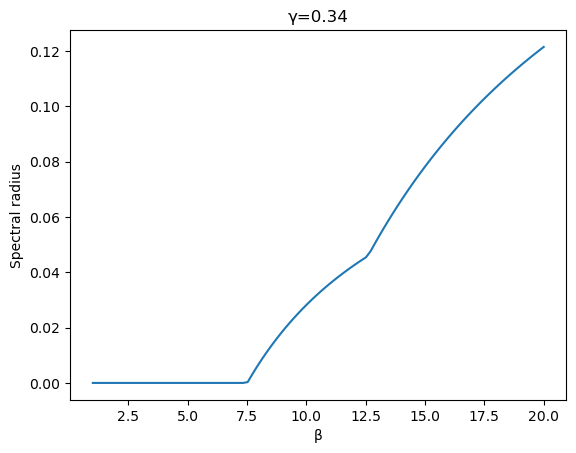

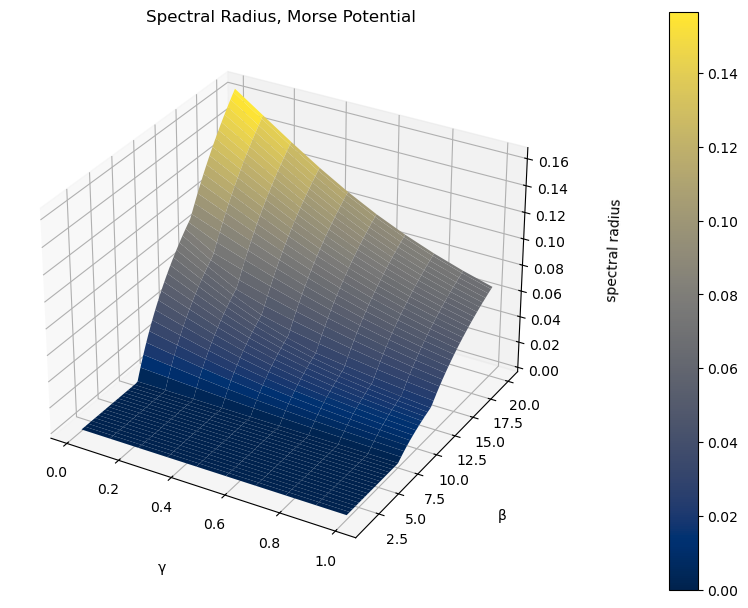

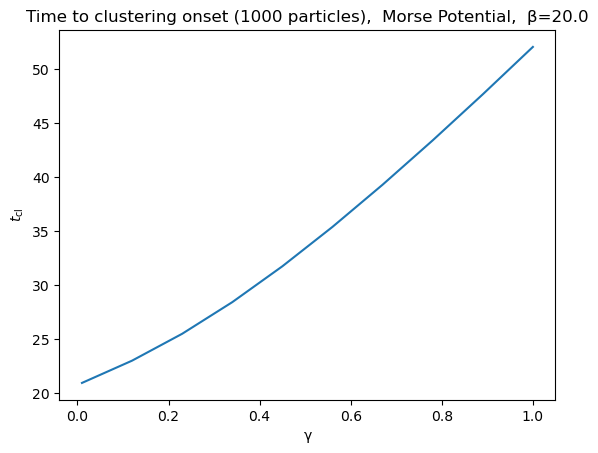

In [182]:
plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, "Morse Potential")

# GEM-$\alpha$

The GEM-$\alpha$ potential is given by 
$$W(r) = -e^{-\Big(\frac{\|r\|}{\sqrt{2\sigma^2}}\Big)^\alpha}.$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by
$$\hat{W}(k) =  \int^{L/2}_{-L/2} W(r)\cos{(kr)}dr, $$
and we use numerical quadrature again to evaluate it.

In [164]:
from scipy.integrate import quad

L  = 10
sigma = np.sqrt(0.5)
alpha  = 4.0

def integrand_GEM(r, k):
    res = -np.exp( -( np.abs(r)/np.sqrt(2*(sigma**2)) )**alpha ) * np.cos(k*r)
    return res 


def W_hat_GEM(k):
    #integrate numerically
    W_hat_k = quad(integrand_GEM, -L/2, L/2, args = (k,))
    return W_hat_k[0]


In [165]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 100
beta_list = np.linspace(1, 20, N_beta)

N_gamma = 10
gamma_list = np.linspace(0.01, 1, N_gamma)

dim = 50    # Pick large enough such that results converge.

k_max = 50  # Pick large enough such that results converge.

spectral_radius = compute_spectral(W_hat_GEM, k_max, beta_list, gamma_list, L, dim)

Testing beta  1.0
Testing beta  1.1919191919191918
Testing beta  1.3838383838383839
Testing beta  1.5757575757575757
Testing beta  1.7676767676767677
Testing beta  1.9595959595959596
Testing beta  2.1515151515151514
Testing beta  2.3434343434343434
Testing beta  2.5353535353535355
Testing beta  2.727272727272727
Testing beta  2.919191919191919
Testing beta  3.111111111111111
Testing beta  3.3030303030303028
Testing beta  3.494949494949495
Testing beta  3.686868686868687
Testing beta  3.8787878787878785
Testing beta  4.070707070707071
Testing beta  4.262626262626263
Testing beta  4.454545454545454
Testing beta  4.646464646464646
Testing beta  4.838383838383838
Testing beta  5.03030303030303
Testing beta  5.222222222222222
Testing beta  5.4141414141414135
Testing beta  5.6060606060606055
Testing beta  5.797979797979798
Testing beta  5.98989898989899
Testing beta  6.181818181818182
Testing beta  6.373737373737374
Testing beta  6.565656565656565
Testing beta  6.757575757575757
Testing beta

In [166]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )

Linear stability analysis result for critical Beta:  5.98989898989899


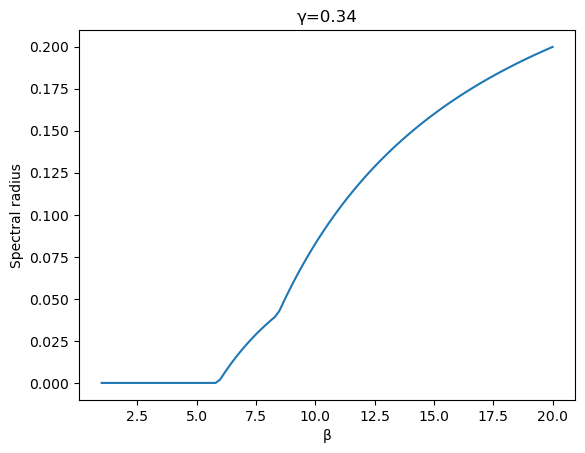

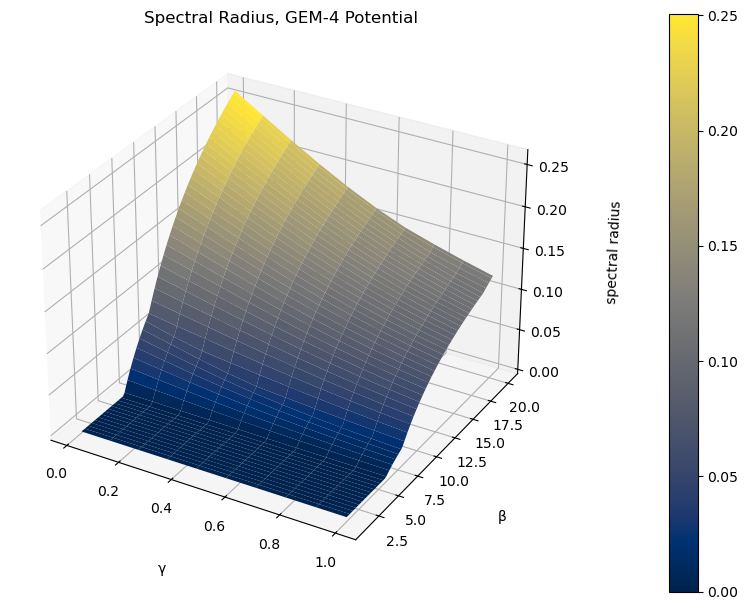

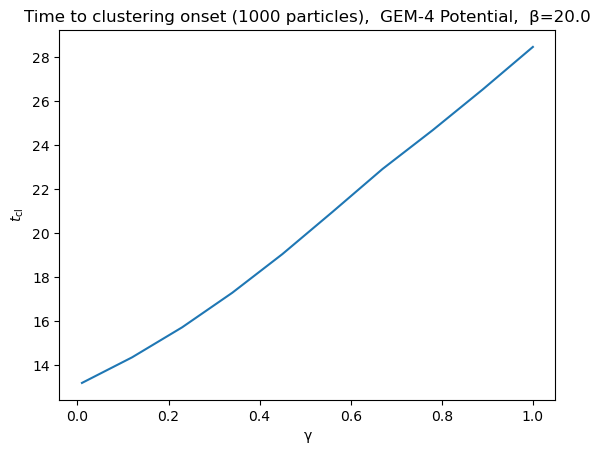

In [175]:

plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, "GEM-4 Potential")